In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

import sys
sys.path.append("..")
from src.evaluacion.backtesting import walk_forward


In [87]:
ruta = "../data/processed/tabla_features.parquet"
df = pd.read_parquet(ruta)
df = df.sort_values("datetime_utc")
df = df[df["entrenable"]]  


In [88]:
# --- Split temporal train/test (holdout de 6 meses) ---
# El test es el tramo FINAL de la serie: simula el futuro y se deja intacto
# hasta la evaluacion final (no se usa para decidir ni tunear nada).
ultima_fecha = df["datetime_utc"].max()
corte = ultima_fecha - pd.DateOffset(months=6)

train = df[df["datetime_utc"] < corte]
test = df[df["datetime_utc"] >= corte]

print(f"Fecha de corte: {corte}")
print(f"Train: {len(train):>6} filas | {train['datetime_utc'].min()} -> {train['datetime_utc'].max()}")
print(f"Test:  {len(test):>6} filas | {test['datetime_utc'].min()} -> {test['datetime_utc'].max()}")
print("NaN en precio_lag_24 dentro de test:", test["precio_lag_24"].isna().sum())


Fecha de corte: 2025-12-29 22:00:00+00:00
Train:  25871 filas | 2023-01-07 23:00:00+00:00 -> 2025-12-29 21:00:00+00:00
Test:    4369 filas | 2025-12-29 22:00:00+00:00 -> 2026-06-29 22:00:00+00:00
NaN en precio_lag_24 dentro de test: 0


In [89]:
naive_d1 = test["precio_lag_24"]
naive_d7 = test["precio_lag_168"]
naive_media = test["precio_media_24"]
target = test["precio_espana"]

In [90]:
def evaluar(y_real, y_pred):
    # sMAPE a mano: np.abs sirve tanto para Series (baselines) como para
    # arrays numpy (predicciones de los modelos). Denominador = media de los
    # dos absolutos. .mean() al final para que sea un escalar, no una Serie.
    smape = (np.abs(y_pred - y_real) / ((np.abs(y_real) + np.abs(y_pred)) / 2)).mean()

    diccionario = {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": root_mean_squared_error(y_real, y_pred),
        "MAPE": mean_absolute_percentage_error(y_real, y_pred),
        "sMAPE": smape,
    }
    return diccionario


In [91]:
df_metricas = pd.DataFrame({
    "naive_d1": evaluar(target, naive_d1),
    "naive_d7": evaluar(target, naive_d7),
    "naive_media": evaluar(target, naive_media),
})
df_metricas

,naive_d1,naive_d7,naive_media
MAE,1.549797e+01,2.580138e+01,3.055077e+01
RMSE,2.368820e+01,3.773770e+01,3.911476e+01
MAPE,2.214588e+14,8.104959e+14,4.618090e+15
sMAPE,7.747461e-01,9.789116e-01,9.434148e-01


## Baselines: resultados e interpretación

Evaluamos tres baselines sobre el **test** (6 meses finales, caja cerrada) con la función `evaluar`:

| Baseline | MAE | RMSE | sMAPE | MAPE |
|---|---|---|---|---|
| naive_d1 (precio de ayer) | **15,5** | 23,69 | 0,775 | inf |
| naive_d7 (hace 7 días) | 25,8 | 37,74 | 0,979 | inf |
| naive_media (media 24h) | 30,55 | 39,11 | 0,943 | inf |

**Lectura:**

- **`naive_d1` es el baseline a batir (MAE ≈ 15,5 €/MWh).** El precio spot tiene una autocorrelación diaria muy fuerte: el precio de mañana se parece mucho al de hoy. Cualquier modelo (XGBoost, LSTM) debe bajar de 15,5 para justificar su valor.
- **La media móvil es la peor** (MAE 30,55): al suavizar, se come los picos y valles de un mercado volátil.
- **MAPE = inf**: 798/4.369 horas (18%) tienen precio ≤ 1 €/MWh, incluido negativos (mín −9,82). Al dividir entre valores ~0 el MAPE explota → **inservible en este dominio**. Reportamos MAE y RMSE como métricas principales.
- **RMSE ≫ MAE** (~1,5×): hay errores grandes concentrados en los picos de precio, que el RMSE penaliza.


In [92]:
diccionario_volumenes = {
    "1 MW": 8760,
    "100 MW": 876000,
    "1 GW": 8760000,
}
metricas = df_metricas.loc["MAE"]

# Coste anual del error = MAE (EUR/MWh) * volumen (MWh/año). Una columna por escenario.
df_coste = pd.DataFrame({
    etiqueta: metricas * volumen
    for etiqueta, volumen in diccionario_volumenes.items()
})

# Formato visual: separador de miles estilo español y resaltado del baseline mas barato.
(
    df_coste.style
    .format(lambda x: f"{x:,.0f} €".replace(",", "."))
    .highlight_min(axis=0, props="background-color:#c6efce; color:#006100; font-weight:bold;")
    .set_caption("Coste anual del error de predicción (€/año) por volumen gestionado")
)


,1 MW,100 MW,1 GW
naive_d1,135.762 €,13.576.223 €,135.762.230 €
naive_d7,226.020 €,22.602.006 €,226.020.055 €
naive_media,267.625 €,26.762.474 €,267.624.743 €


In [93]:
df["meses"] = df["datetime_utc"].dt.to_period("M") 
meses = df["meses"].sort_values().unique()
print(len(meses))
print(meses[:3])

42
<PeriodArray>
['2023-01', '2023-02', '2023-03']
Length: 3, dtype: period[M]


C:\Users\jaime\AppData\Local\Temp\ipykernel_16340\322589413.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["meses"] = df["datetime_utc"].dt.to_period("M")


In [94]:
# Walk-forward del baseline naive D-1, ahora vía la función reutilizable de src.
# El baseline ignora el train (tr) y predice con la columna lag.
df_dw = walk_forward(df, "precio_espana", lambda tr, te: te["precio_lag_24"])

media = df_dw["MAE"].mean()
desviacion_tipica = df_dw["MAE"].std()
print(f"la media es de {media} ")
print(f"la desviación típica es de {desviacion_tipica}")


la media es de 18.25854897645154 
la desviación típica es de 4.759853291986678


In [95]:
df_dw.sort_values("MAE", ascending = False)

,mes,MAE,RMSE,MAPE,sMAPE
9,2024-10,24.956922,33.027889,1.124750e+15,0.516434
13,2025-02,24.747574,32.754018,4.636756e-01,0.312441
12,2025-01,23.733091,33.606100,5.587127e+13,0.413973
10,2024-11,23.648181,35.711645,7.331314e-01,0.320369
14,2025-03,22.976035,31.919731,1.190669e+15,0.811001
21,2025-10,22.928653,33.173490,3.846016e+14,0.528146
22,2025-11,22.324255,28.479229,7.138344e+14,0.602745
11,2024-12,22.152352,32.286718,7.896601e-01,0.327928
17,2025-06,21.413194,32.946270,2.046886e+15,0.560357
7,2024-08,21.112809,32.889852,7.274524e+15,0.420345


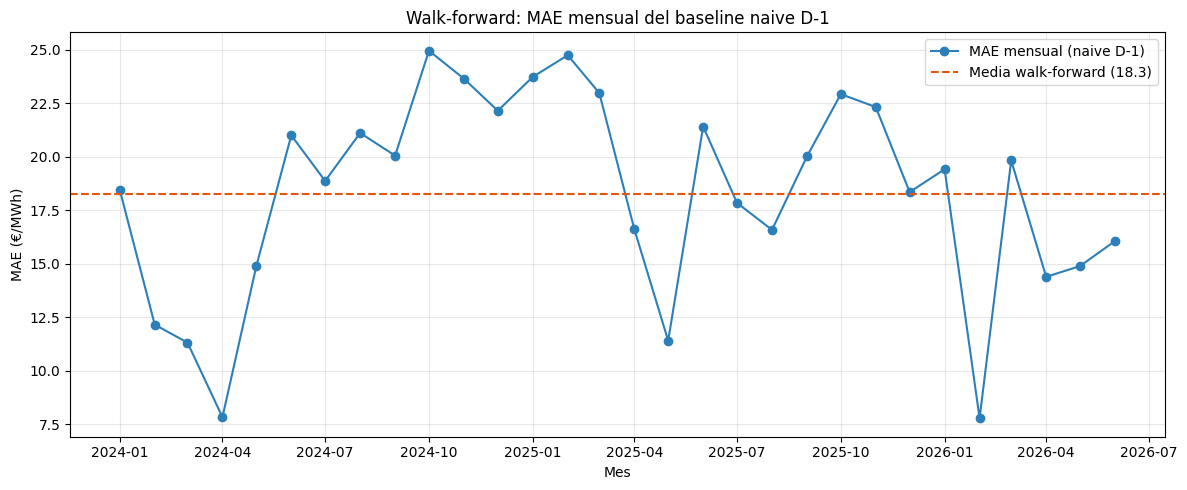

In [96]:
# Ordena por mes y convierte el Period a fecha para el eje X
df_plot = df_dw.sort_values("mes").copy()
df_plot["mes_ts"] = df_plot["mes"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_plot["mes_ts"], df_plot["MAE"], marker="o", color="#2c7fb8",
        label="MAE mensual (naive D-1)")
ax.axhline(df_plot["MAE"].mean(), color="#e6550d", linestyle="--",
           label=f"Media walk-forward ({df_plot['MAE'].mean():.1f})")

ax.set_title("Walk-forward: MAE mensual del baseline naive D-1")
ax.set_xlabel("Mes")
ax.set_ylabel("MAE (€/MWh)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/walkforward_mae.png", dpi=150, bbox_inches="tight")
plt.show()

In [97]:
df_dw["mes"] = df_dw["mes"].dt.to_timestamp()
df_dw = df_dw.rename(columns = {"MAE":"mae_naive_d1"})
df_dw.to_parquet("../reports/baseline_walkforward.parquet")

